# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [5]:
def calculate_resolution( clean_beam, current_beam):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - current_beam**2)
    final_bmin_as = np.sqrt(bmin_as**2 - current_beam**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [6]:
def calculate_resolution2( clean_beam, current_beam):
    from radio_beam import Beam
    bmaj_clean = clean_beam['bmaj']
    bmin_clean = clean_beam['bmin']
    bpa_deg_clean = clean_beam['beam_pa']

    bmaj_current = current_beam['bmaj']
    bmin_current = current_beam['bmin']
    bpa_deg_current = current_beam['beam_pa']

    beam_orig =  Beam(major=bmaj_current*u.arcsec, minor=bmin_current*u.arcsec, pa=bpa_deg_current)
    beam_target = Beam(major=bmaj_clean*u.arcsec, minor=bmin_clean*u.arcsec, pa=bpa_deg_clean)

    beam_final = beam_target.deconvolve(beam_orig)

    #return values in a dict
    final_resolution = {'bmaj': beam_final.major.to(u.arcsec).value,
                        'bmin': beam_final.minor.to(u.arcsec).value,
                        'beam_pa': beam_final.pa.to(u.deg).value}

    return final_resolution


In [7]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [8]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

# Data

In [9]:
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88, 'disk_name': 'Elias27'}
data = Elias27

# UVtable
dir = "../../data/uvtable/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

geom = Geometry(inc, pa, dra, ddec)

In [10]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 10316.430545274563, q_max data: 12213086.334906872


In [11]:
Rmax = 2*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 1113
Rmax = 3.76


In [12]:
imsize = N

In [13]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [14]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [15]:
best_N50 = {'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161} #27m59s

In [16]:
best = best_N50

In [17]:
#FWHM_frank2d_N100= 0.02276732753216587
#FWHM_frank2d_N50 = 0.02246119946612007
#FWHM_frank2d = FWHM_frank2d_N100

In [18]:
frank2d = Frank2D(N, Rmax)

In [20]:
start_time = time.time()
frank2d.process_vis(uvtable)
frank2d.fit(kernel_params = best, rtol = 1e-10, precond_type='ilu')

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Creating sparse linear system...


        +  Kernel = 0.18  min |  10.87 seconds
        +   CSC = 0.00  min |  0.14 seconds
        +  ILU = 0.64  min |  38.36 seconds
        +  Building system = 0.83  min |  49.90 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 10/50000 [00:02<3:46:09,  3.68 iterations/s]


            +  BiCGStab = 0.05  min |  2.72 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.005988209486557158,
 'iterations': 10,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.36  min |  21.87 seconds
--> times building full visibility model = 0.37  min |  22.03 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 1113 took 85.68579268455505 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [21]:
Plot_ = Plot(frank2d, geom_f2d)

In [22]:
zoom = 1.5

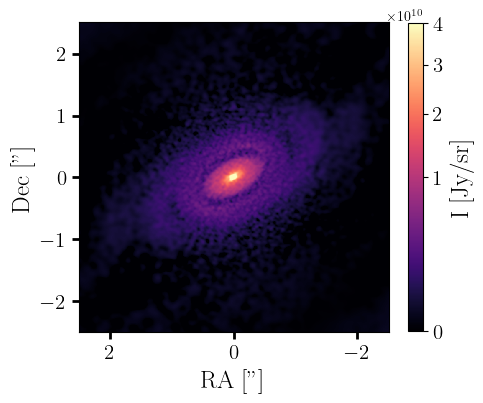

In [23]:
Plot_.intensity(gamma=0.5, zoom=zoom, vmax = 4e10, title="", fig_size=5, 
tick_label_size = 15, label_size = 18, title_size = 18)

### Open fits file
Of image regridded in CASA with imregrid, the same image from where we got the CLEAN model uvtable.

In [24]:
from astropy.io import fits
dir_  = "../../data/.image_fits/"
disk = 'CLEAN_Elias27_dotimage_fov7p52_imsize1113.fits'

fits_name = dir_ + disk

In [25]:
hdul = fits.open(fits_name)

In [26]:
import matplotlib.colors as colors

### CLEAN model imregridded

In [27]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [28]:
hdr = hdul[0].header
data = hdul[0].data 

In [29]:
# beam
bmaj = hdr.get('BMAJ') # degrees
bmaj_as = bmaj * 3600 # arcseconds
bmin = hdr.get('BMIN')
bmin_as = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [30]:
w = WCS(hdr)

In [31]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 1113, 1113) -> squeezed: (1113, 1113)


In [32]:
data = data_squeezed

In [33]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [34]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



In [35]:
xmax

3.7566527596305135

In [36]:
cellsize_clean = np.abs(ra_off_arcsec[0][1]-ra_off_arcsec[0][0])
cellsize_clean

0.006756569863133777

In [37]:
pixel_scale_x_as = cellsize_clean
pixel_scale_y_as = cellsize_clean

bmaj_pix = bmaj_as/pixel_scale_x_as
bmin_pix = bmin_as/pixel_scale_y_as
angle_display = 90.0 - bpa 

In [38]:
Rmax*2 / imsize  

0.006756513926325247

In [39]:
xmax

3.7566527596305135

In [40]:
bmin_as, bmaj_as

(0.050173234194527995, 0.054138079285632)

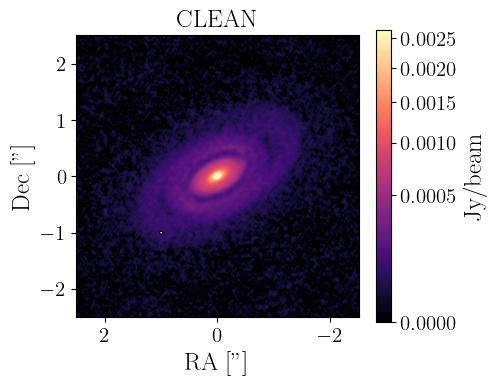

In [41]:
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(5,5))
norm = colors.PowerNorm(gamma=0.5, vmin=0, vmax = img.max()/2)
ax = plt.gca()

im = ax.imshow(
    img,
    extent=[Rmax, -Rmax, -Rmax, Rmax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)


ax.set_xlabel('RA ["]', size=18)
ax.set_ylabel('Dec ["]', size=18)
ax.set_xlim(xmax/zoom, xmin/zoom)
ax.set_ylim(ymax/zoom, ymin/zoom)
ax.set_title(r'CLEAN', size=18)
plt.tick_params(axis='both', labelsize=15)

cbar = plt.colorbar(im, ax=ax, shrink=0.65)
cbar.set_label( hdr.get('BUNIT'), size=18)
cbar.ax.tick_params(labelsize=15)
cbar.update_ticks()
ax.grid(False)

xloc = xmin + 0.5 * (xmax - xmin)
yloc = ymin + 0.5 * (ymax - ymin)


beam = patches.Ellipse(
    (1, -1), 
    width=bmaj_as, 
    height=bmin_as, 
    angle=angle_display, 
    facecolor='white', 
    edgecolor='black', 
    linewidth=0.8, 
    zorder=5
)

ax.add_patch(beam)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Comparing with CLEAN

In [42]:
fwhm_clean_geom = np.sqrt(bmaj_as * bmin_as)
fwhm_clean_geom

0.05211796744732031

In [43]:
FWHM_frank2d = 25.5e-3 # arcsec
fwhm_frank2d = np.sqrt(fwhm_clean_geom**2 - FWHM_frank2d**2)

In [44]:
pixel_scale_arcsec = (frank2d.x_grid[0][1] - frank2d.x_grid[0][0]) * rad_to_arcsec
cellsize_f2d = pixel_scale_arcsec

In [45]:
clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

In [46]:
import scipy.ndimage as ndimage
from scipy.ndimage import gaussian_filter

sigma_pixels_f2d = fwhm_frank2d / (2.35482 * pixel_scale_arcsec)
I_frank2d_convolved_2d = gaussian_filter(frank2d.intensity_model, sigma=sigma_pixels_f2d)
I_frank2d_convolved_2d *= clean_area 

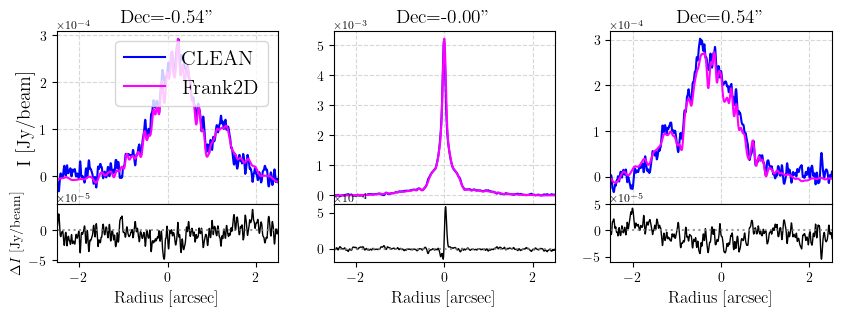

In [47]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Ejemplo: Un corte desplazado a la izq, el central, y uno a la derecha
indices_seleccionados = [
    int(N/2 - 80), 
    int(N/2),      
    int(N/2 + 80)
]

# Ajustamos el tamaño de la figura para que sea más ancha que alta (1 fila, 3 columnas)
fig = plt.figure(figsize=(10, 3)) 

# Grid de 1 fila x 3 columnas
outer_grid = gridspec.GridSpec(1, 3, wspace=0.25, hspace=0.2)

for i, idx in enumerate(indices_seleccionados):
    
    # --- 1. Extracción de Datos ---
    x = frank2d.x_grid[0] * rad_to_arcsec
    y_i = frank2d.y_grid[idx][0] * rad_to_arcsec
    
    I_f2d_conv = I_frank2d_convolved_2d[idx]
    I_clean = img[idx]
    
    # Cálculo de la diferencia (Residual Absoluto)
    diff = I_f2d_conv - I_clean

    # --- 2. Configuración de Subplots ---
    # outer_grid[i] ahora recorre 0, 1, 2
    inner_grid = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer_grid[i], 
        wspace=0, hspace=0, 
        height_ratios=[3, 1]
    )
    ax_main = plt.subplot(inner_grid[0])
    ax_res = plt.subplot(inner_grid[1], sharex=ax_main)

    # --- 3. Plot Principal ---
    lbl_clean = "CLEAN" if i == 0 else None
    lbl_frank = "Frank2D" if i == 0 else None
    
    ax_main.plot(x, I_clean, color='blue', label=lbl_clean, linestyle='-')
    ax_main.plot(x, I_f2d_conv, color='magenta', ls='-', label=lbl_frank)
    
    # --- 4. Plot Residual ---
    ax_res.plot(x, diff, color='black', lw=1)
    ax_res.axhline(0, color='gray', linestyle=':', alpha=0.8)
    
    # --- 5. Estética y Textos ---
    title_str = f'Dec={y_i:.2f}"'
    ax_main.set_title(title_str, size=14)
    
    # Ajuste de límites X
    limit_x = Rmax/1.5
    ax_main.set_xlim(-limit_x, limit_x)
    
    ax_main.grid(True, ls='--', alpha=0.5)
    ax_main.tick_params(labelbottom=False) 
    
    # ETIQUETAS EJE Y: Solo en el primer gráfico (i=0)
    if i == 0: 
        ax_main.set_ylabel('I [Jy/beam]', size=14)
        ax_res.set_ylabel(r'$\Delta I$ [Jy/beam]', size=10)
    
    # ETIQUETAS EJE X: En todos los gráficos (porque solo hay una fila)
    ax_res.set_xlabel('Radius [arcsec]', size=12)

    # --- 6. Líneas Verticales (Ahora en el plot central, i=1) ---
    # Corregí el "if i == 416" por "if i == 1" (el del medio de los 3)
    if i == 143:
        vlines = [
            (-0.35, '--', 'blob'),
            (-0.49, ':',  'gap'),
            (-0.6,  '-',  'ring'),
            (-0.68, ':',  None),
            (-0.8,  '-',  None)
        ]
        
        for pos, style, label in vlines:
            for ax in [ax_main, ax_res]:
                lbl = label if ax == ax_main else None
                ax.axvline(pos, color='gray', linestyle=style, linewidth=0.8, label=lbl)

        # Leyenda de estructuras (blob, gap, ring) en el plot central
        ax_main.legend(fontsize=10, loc='upper right')

    # --- 7. Formato Científico ---
    for ax in [ax_main, ax_res]:
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2), useMathText=True)
        ax.yaxis.get_offset_text().set_fontsize(8)
        ax.tick_params(axis='both', labelsize=10)

    # Leyenda principal (CLEAN vs Frank) solo en el primer plot
    if i == 0: 
        ax_main.legend(fontsize=15, loc='upper right')

plt.tight_layout()
plt.show()

plt.show()

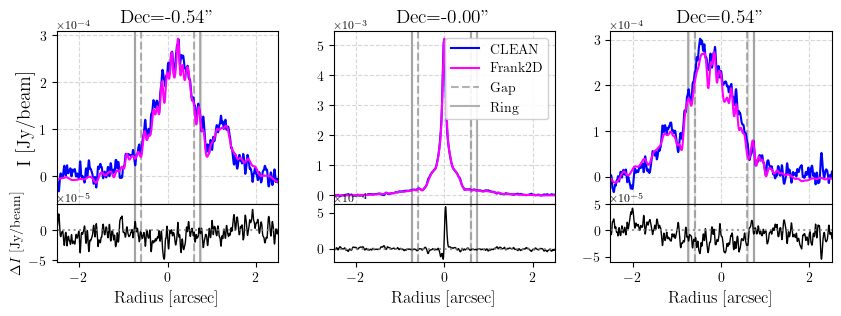

In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- DATOS ELIAS 27 (mas) ---
# Formato: (Posición, Error_inferior, Error_superior)
# Gap D69: 596 +8/-7
gap_data = (596, 7, 8) 
# Anillo B86: 741 +/- 9
ring_data = (741, 9, 9)

# Ajustamos el tamaño de la figura
fig = plt.figure(figsize=(10, 3)) 

# Grid de 1 fila x 3 columnas
outer_grid = gridspec.GridSpec(1, 3, wspace=0.25, hspace=0.2)

for i, idx in enumerate(indices_seleccionados):
    
    # --- 1. Extracción de Datos ---
    x = frank2d.x_grid[0] * rad_to_arcsec
    y_i = frank2d.y_grid[idx][0] * rad_to_arcsec
    
    I_f2d_conv = I_frank2d_convolved_2d[idx]
    I_clean = img[idx]
    diff = I_f2d_conv - I_clean

    # --- 2. Configuración de Subplots ---
    inner_grid = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer_grid[i], 
        wspace=0, hspace=0, 
        height_ratios=[3, 1]
    )
    ax_main = plt.subplot(inner_grid[0])
    ax_res = plt.subplot(inner_grid[1], sharex=ax_main)

    # --- 3. Plot Principal ---
    # ACTIVAR LABELS SOLO SI ESTAMOS EN EL MEDIO (i == 1)
    lbl_clean = "CLEAN" if i == 1 else None
    lbl_frank = "Frank2D" if i == 1 else None
    
    ax_main.plot(x, I_clean, color='blue', label=lbl_clean, linestyle='-')
    ax_main.plot(x, I_f2d_conv, color='magenta', ls='-', label=lbl_frank)
    
    # --- 4. Plot Residual ---
    ax_res.plot(x, diff, color='black', lw=1)
    ax_res.axhline(0, color='gray', linestyle=':', alpha=0.8)

    # --- 5. ESTRUCTURAS (Gaps y Anillos) ---
    # Se agregan en TODOS los gráficos (i=0,1,2)
    # Deben aparecer simétricos (+ y -)

    sides = [1, -1] # Multiplicador para lado derecho e izquierdo

    for side in sides:
        # --- GAP (D69) ---
        pos = gap_data[0] / 1000.0  # a arcsec
        err_low = gap_data[1] / 1000.0
        err_high = gap_data[2] / 1000.0
        
        # Lógica para etiqueta: Solo en el plot del medio, solo en el lado positivo
        lbl_gap = "Gap" if (i == 1 and side == 1) else None
        
        # Posición central (considerando el signo del lado)
        center = pos * side
        
        # Calcular los bordes del área sombreada (span)
        # Si estamos en el lado positivo: [pos - low, pos + high]
        # Si estamos en el lado negativo: [-pos - high, -pos + low]
        if side == 1:
            span_min, span_max = center - err_low, center + err_high
        else:
            span_min, span_max = center - err_high, center + err_low

        for ax in [ax_main, ax_res]:
            ax.axvline(center, color='gray', linestyle='--', alpha=0.6, zorder=0, label=lbl_gap if ax==ax_main else None)
            ax.axvspan(span_min, span_max, color='gray', alpha=0.2, zorder=0)

        # --- ANILLO (B86) ---
        pos = ring_data[0] / 1000.0
        err_low = ring_data[1] / 1000.0
        err_high = ring_data[2] / 1000.0
        
        lbl_ring = "Ring" if (i == 1 and side == 1) else None
        
        center = pos * side
        if side == 1:
            span_min, span_max = center - err_low, center + err_high
        else:
            span_min, span_max = center - err_high, center + err_low

        for ax in [ax_main, ax_res]:
            ax.axvline(center, color='gray', linestyle='-', alpha=0.6, zorder=0, label=lbl_ring if ax==ax_main else None)
            ax.axvspan(span_min, span_max, color='gray', alpha=0.2, zorder=0)


    # --- 6. Estética y Textos ---
    title_str = f'Dec={y_i:.2f}"'
    ax_main.set_title(title_str, size=14)
    
    limit_x = Rmax/1.5
    ax_main.set_xlim(-limit_x, limit_x)
    
    ax_main.grid(True, ls='--', alpha=0.5)
    ax_main.tick_params(labelbottom=False) 
    
    # ETIQUETAS EJE Y: Solo a la izquierda (i=0)
    if i == 0: 
        ax_main.set_ylabel('I [Jy/beam]', size=14)
        ax_res.set_ylabel(r'$\Delta I$ [Jy/beam]', size=10)
    
    # ETIQUETAS EJE X: En todos
    ax_res.set_xlabel('Radius [arcsec]', size=12)

    # LEYENDA CENTRAL
    # Como definimos los labels solo cuando i==1, llamamos a legend aquí
    if i == 1: 
        # loc='upper right' o 'best' según donde moleste menos
        ax_main.legend(fontsize=10, loc='upper right', framealpha=0.9)

    # Formato Científico
    for ax in [ax_main, ax_res]:
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2), useMathText=True)
        ax.yaxis.get_offset_text().set_fontsize(8)
        ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

NameError: name 'bmin_clean' is not defined

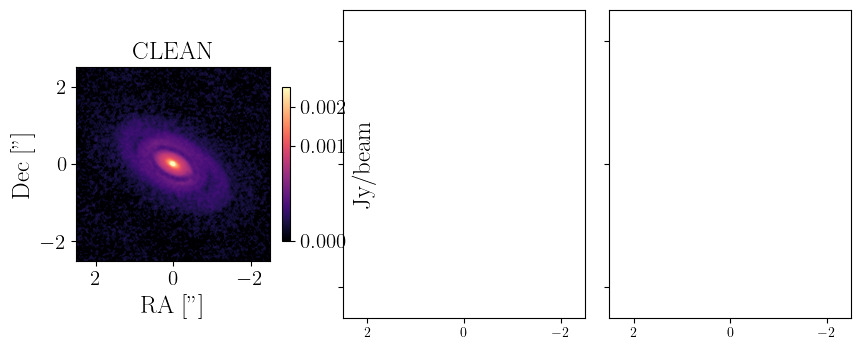

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredEllipse

pixel_scale = (frank2d.x_grid[0][1] - frank2d.x_grid[0][0]) * rad_to_arcsec

I_GT_final = I_frank2d_convolved_2d
I_CLEAN_final = np.nan_to_num(img, nan=0.0)


with np.errstate(divide='ignore', invalid='ignore'):
    I_Residual = np.abs((I_CLEAN_final - I_GT_final))

zoom = 1.5
limit_val = Rmax / zoom


extent = [Rmax, -Rmax, -Rmax, Rmax]
vmin_main = 0
vmax_main = max(np.nanmax(I_GT_final), np.nanmax(I_CLEAN_final))

plots_config = [
    {
        "data": I_CLEAN_final, 
        "title": "CLEAN", 
        "cmap": "magma", 
        "norm": colors.PowerNorm(gamma=0.5, vmin=0, vmax=vmax_main/2),
        "is_residual": False
    },
    {
        "data": I_GT_final, 
        "title": "Frankenstein2D", 
        "cmap": "magma", 
        "norm": colors.PowerNorm(gamma=0.5, vmin=0, vmax=vmax_main/2),
        "is_residual": False
    },
    {
        "data": I_Residual, 
        "title": "Residual", 
        "cmap": "RdBu",
        "norm": colors.LogNorm(vmin=1e-6, vmax=1e-1), # Escala logarítmica para el error
        "is_residual": True
    }
]

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.1) # Espacio entre paneles

for i, ax in enumerate(axes):
    cfg = plots_config[i]
    
    im = ax.imshow(
        cfg["data"],
        extent=extent,
        origin='lower', # Importante para coordenadas astronómicas
        cmap=cfg["cmap"],
        norm=cfg["norm"],
    )

    # B) ESTÉTICA DE EJES (Estilo Source 1 - Fuentes Grandes)
    ax.set_xlabel('RA ["]', size=18)
    if i == 0:
        ax.set_ylabel('Dec ["]', size=18)
    
    # Aplicar Zoom
    ax.set_xlim(limit_val, -limit_val) # Invertido para RA
    ax.set_ylim(-limit_val, limit_val)
    
    ax.set_title(cfg["title"], size=18)
    ax.tick_params(axis='both', labelsize=15)
    ax.grid(False)

    # C) COLORBAR (Estilo Source 1 - Shrink y Labels grandes)
    # Nota: Usamos una fracción pequeña para no deformar el subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.5, pad=0.05)

    label_cbar = r'$|\Delta I|$' if cfg["is_residual"] else 'Jy/beam'
    cbar.set_label(label_cbar, size=18)
    cbar.ax.tick_params(labelsize=15)
    
    x_beam = 1.8
    y_beam = 1.8

    beam = patches.Ellipse(
        (x_beam, y_beam), 
        width=bmin_clean,   # Asegúrate de usar las variables correctas (arcsec)
        height=bmaj_clean, 
        angle=90+bpa,       # Ángulo corregido para matplotlib (normalmente +90)
        facecolor='white', 
        edgecolor='white', 
        linewidth=1, 
        zorder=10
    )
    ax.add_patch(beam)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()